# Customer Lifetime Value (CLV) Prediction — End-to-End Analysis

This notebook is the narrative walkthrough of the project. Reusable logic lives in `src/`;
this notebook focuses on the story: what we found, why we made each decision, and what it means for the business.

**Workflow:** Data Understanding -> Cleaning -> EDA -> Feature Engineering -> Modeling (single-stage vs two-stage) -> Interpretation -> Business Recommendations


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import joblib
import json

from data.load_data import load_raw_transactions
from data.data_quality import profile_dataframe, quality_report
from data.clean_data import clean_pipeline
from features.build_features import build_feature_target_table
from visualization.eda_plots import (
    plot_customer_revenue_distribution, plot_pareto_concentration,
    plot_purchase_frequency, plot_monthly_revenue_trend, plot_country_revenue
)
from models.evaluate import evaluate_regression
from models.train_single_stage import get_candidate_models, cross_validate_models
from models.train_two_stage import get_stage1_classifiers, cross_validate_stage1, cross_validate_two_stage, get_stage2_regressor

import matplotlib.pyplot as plt
import yaml

with open('../config/config.yaml') as f:
    config = yaml.safe_load(f)

pd.set_option('display.width', 120)
print('Config loaded:', config['split'])


Config loaded: {'calibration_start': '2010-12-01', 'calibration_end': '2011-08-31', 'holdout_start': '2011-09-01', 'holdout_end': '2011-11-30', 'excluded_start': '2011-12-01', 'excluded_end': '2011-12-09'}


## 1. Data Understanding

We load the raw transactional data and profile it before touching anything, to understand
*why* the data is messy rather than blindly cleaning it.

In [2]:
df = load_raw_transactions('../data/raw/online_retail.csv')
print('Raw shape:', df.shape)
profile_dataframe(df)


Raw shape: (541909, 8)


,dtype,missing_count,missing_pct,n_unique
InvoiceNo,str,0,0.00,25900
StockCode,str,0,0.00,4070
Description,str,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[us],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,str,0,0.00,38


In [3]:
report = quality_report(df)
json.dumps(report, indent=2)
print(json.dumps(report, indent=2))


{
  "total_rows": 541909,
  "cancellation_rows": 9288,
  "cancellation_pct": 1.71,
  "non_product_rows": 2668,
  "negative_qty_not_cancellation": 1336,
  "non_positive_price_rows": 2517,
  "missing_customer_id_rows": 135080,
  "missing_customer_id_pct": 24.93,
  "duplicate_rows": 10147,
  "revenue_from_missing_customer": 1447682.12
}


**Findings:** 1.71% cancellations (meaningful business signal, not noise), 2,668 non-product
administrative rows (postage/discount/manual), ~25% of rows missing `CustomerID` (~£1.45M in
untrackable revenue), and 10,147 exact duplicate rows (data export artifacts).

## 2. Data Cleaning

Decision (confirmed with stakeholder): cancellations are **dropped entirely** (simpler, standard
approach for this dataset), non-product rows are excluded, missing CustomerID rows are dropped,
and exact duplicates are removed. Every step is logged so the cleaning is fully auditable.

In [4]:
clean_df = clean_pipeline(df)
clean_df.to_csv('../data/interim/online_retail_cleaned.csv', index=False)
clean_df.head()


Starting rows: 541,909

[drop_cancellations] removed 9,288 rows (541,909 -> 532,621)


[drop_non_product_rows] removed 2,179 rows (532,621 -> 530,442)
[filter_valid_quantity_price] removed 2,504 rows (530,442 -> 527,938)
[drop_missing_customer_id] removed 131,465 rows (527,938 -> 396,473)


[drop_duplicate_rows] removed 5,187 rows (396,473 -> 391,286)

Final rows: 391,286


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Exploratory Data Analysis

Every chart here is treated as a business question, not just a distribution check.

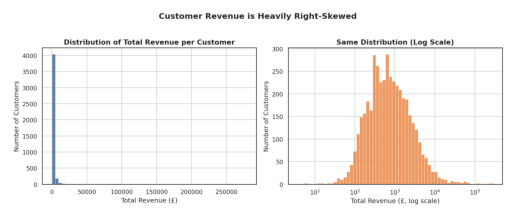

In [5]:
customer_revenue = clean_df.groupby('CustomerID')['Revenue'].sum()
customer_frequency = clean_df.groupby('CustomerID')['InvoiceNo'].nunique()
monthly_revenue = clean_df.groupby(clean_df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
country_revenue = clean_df.groupby('Country')['Revenue'].sum()

plot_customer_revenue_distribution(customer_revenue, '../reports/figures/01_customer_revenue_distribution.png')
plt.figure(); img = plt.imread('../reports/figures/01_customer_revenue_distribution.png'); plt.imshow(img); plt.axis('off'); plt.show()


**Revenue is heavily right-skewed** — median customer revenue is far below the mean, driven by a long tail of high-spenders. This tells us to log-transform the target before modeling.

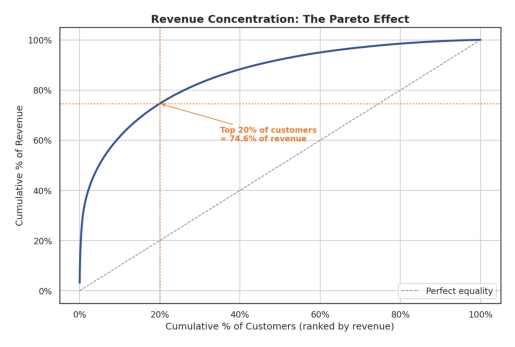

Top 20% of customers generate 74.6% of revenue


In [6]:
rev_at_20 = plot_pareto_concentration(customer_revenue, '../reports/figures/02_pareto_concentration.png')
plt.figure(); img = plt.imread('../reports/figures/02_pareto_concentration.png'); plt.imshow(img); plt.axis('off'); plt.show()
print(f'Top 20% of customers generate {rev_at_20:.1f}% of revenue')


**Classic Pareto concentration.** This alone justifies tiered, segment-based marketing spend rather than a flat budget across all customers.

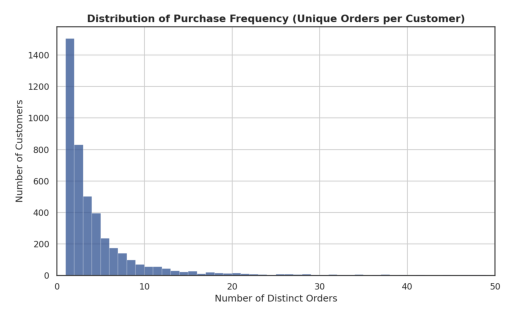

count    4334.000000
mean        4.246654
std         7.642535
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: InvoiceNo, dtype: float64


In [7]:
plot_purchase_frequency(customer_frequency, '../reports/figures/03_purchase_frequency.png')
plt.figure(); img = plt.imread('../reports/figures/03_purchase_frequency.png'); plt.imshow(img); plt.axis('off'); plt.show()
print(customer_frequency.describe())


**Most customers are one-time or occasional buyers** — median of just 2 orders. A large share never return after their first purchase, which foreshadows the zero-inflated target we'll see in Section 5.

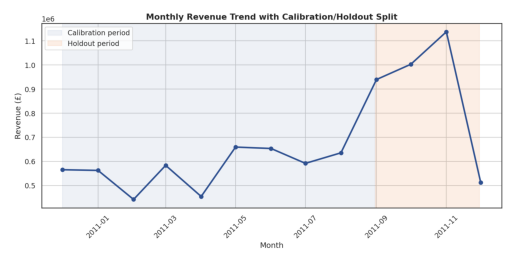

In [8]:
plot_monthly_revenue_trend(monthly_revenue, config['split']['calibration_end'], config['split']['holdout_end'],
                            '../reports/figures/04_monthly_revenue_trend.png')
plt.figure(); img = plt.imread('../reports/figures/04_monthly_revenue_trend.png'); plt.imshow(img); plt.axis('off'); plt.show()


**Confirms the calibration/holdout split lands on strong months** (Sep-Nov, pre-holiday ramp-up), not a seasonal lull — validating our Phase 1 split decision visually.

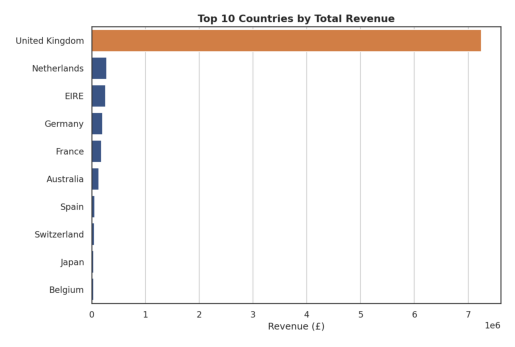

UK share of revenue: 82.8%


In [9]:
plot_country_revenue(country_revenue, '../reports/figures/05_country_revenue.png')
plt.figure(); img = plt.imread('../reports/figures/05_country_revenue.png'); plt.imshow(img); plt.axis('off'); plt.show()
print(f"UK share of revenue: {country_revenue['United Kingdom'] / country_revenue.sum() * 100:.1f}%")


**UK dominates at 82.8% of revenue** — informs our decision to simplify `Country` into a single `is_uk` binary feature rather than one-hot encoding 37 sparse categories.

## 4. Feature Engineering (RFM)

Features are computed **only** from the calibration period (Dec 2010 - Aug 2011). The target
(`future_revenue`) comes from the holdout period (Sep - Nov 2011). Customers with no calibration
history are excluded (cold-start, out of scope).

In [10]:
calib_df = clean_df[(clean_df['InvoiceDate'] >= config['split']['calibration_start']) &
                     (clean_df['InvoiceDate'] <= config['split']['calibration_end'])]
holdout_df = clean_df[(clean_df['InvoiceDate'] >= config['split']['holdout_start']) &
                       (clean_df['InvoiceDate'] <= config['split']['holdout_end'])]

snapshot_date = pd.Timestamp(config['split']['calibration_end'])
feature_table = build_feature_target_table(calib_df, holdout_df, snapshot_date)
feature_table.to_csv('../data/processed/clv_feature_table.csv')

print('Feature table shape:', feature_table.shape)
feature_table.head()


Feature table shape: (3309, 10)


,frequency,monetary,total_quantity,unique_products,recency_days,tenure_days,avg_order_value,is_one_time_buyer,is_uk,future_revenue
CustomerID,,,,,,,,,,
12346,1,77183.60,74215,1,224,224,77183.6000,1,1,0.00
12347,5,2790.86,1590,82,28,266,558.1720,0,0,1294.32
12348,3,1167.24,2116,21,147,257,389.0800,0,0,270.00
12350,1,294.40,196,16,209,209,294.4000,1,0,0.00
12352,4,641.51,249,24,161,195,160.3775,0,0,744.23


In [11]:
zero_target_pct = (feature_table['future_revenue'] == 0).mean() * 100
print(f'% of customers with future_revenue = 0 (churned in holdout): {zero_target_pct:.1f}%')
feature_table.corr(numeric_only=True)['future_revenue'].sort_values(ascending=False)


% of customers with future_revenue = 0 (churned in holdout): 43.9%


future_revenue       1.000000
monetary             0.824586
total_quantity       0.665606
frequency            0.450936
unique_products      0.325973
avg_order_value      0.115253
tenure_days          0.105320
is_uk               -0.049977
is_one_time_buyer   -0.109956
recency_days        -0.130085
Name: future_revenue, dtype: float64

**Key finding: 43.9% of customers generated zero revenue in the holdout window.** This
zero-inflation is the single most important characteristic of our target, and it directly
motivates the two-stage modeling approach below.

## 5. Modeling: Single-Stage Baseline

We first try treating this as one regression problem, predicting `future_revenue` (including zeros)
directly. Target is log1p-transformed given the skew found in EDA.

In [12]:
X = feature_table.drop(columns=['future_revenue'])
y = feature_table['future_revenue']

single_stage_models = get_candidate_models()
single_stage_results = cross_validate_models(X, y, single_stage_models, n_splits=5)
single_stage_results


,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE_on_nonzero_only,pct_nonzero_actuals
model,,,,,,,
RandomForest,5.334740e+02,6.440160e+06,2.430446e+03,4.577600e-01,4.502600e-01,94.828,56.09
XGBoost,5.519340e+02,7.927955e+06,2.607384e+03,4.874200e-01,4.803400e-01,90.546,56.09
LightGBM,5.785320e+02,9.794305e+06,2.855422e+03,4.185200e-01,4.105000e-01,92.038,56.09
LinearRegression,2.357377e+11,1.839439e+26,6.065380e+12,-6.473295e+19,-6.562650e+19,923.220,56.09
Ridge,2.365151e+11,1.851591e+26,6.085382e+12,-6.516060e+19,-6.606006e+19,922.746,56.09


**Linear/Ridge regression catastrophically fail** here (MAE in the billions) — combining a
log1p target transform with an unbounded linear model means small log-space errors on unusual
feature combinations turn into astronomical £ errors after `expm1()`. Tree-based models don't
have this problem since their predictions are bounded by observed training leaf values.

**Random Forest wins** among viable models (MAE £533, RMSE £2,428), but MAPE (~95% on customers
who did return) is high — a sign this single model is struggling to jointly learn "who returns"
and "how much they spend."

## 6. Modeling: Two-Stage Hurdle Model

Given the 43.9% zero-inflation, we decompose the problem: a classifier predicts return probability,
and a regressor (trained only on returners) predicts spend amount.

In [13]:
y_binary = (y > 0).astype(int)
stage1_results = cross_validate_stage1(X, y_binary, get_stage1_classifiers())
stage1_results


,Accuracy,Precision,Recall,ROC_AUC
model,,,,
LogisticRegression,0.680879,0.732752,0.680656,0.743326
RandomForestClassifier,0.680273,0.733752,0.679164,0.743093
XGBoostClassifier,0.663654,0.709155,0.681613,0.727893


In [14]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000, random_state=42)
two_stage_metrics = cross_validate_two_stage(X, y, clf, n_splits=5, random_seed=42)

comparison = pd.DataFrame({
    'Single-stage (RandomForest)': single_stage_results.loc['RandomForest'],
    'Two-stage (Hurdle)': pd.Series(two_stage_metrics)
})
comparison


,Single-stage (RandomForest),Two-stage (Hurdle)
MAE,5.334740e+02,5.273300e+02
MSE,6.440160e+06,4.717401e+06
RMSE,2.430446e+03,2.148540e+03
R2,4.577600e-01,4.682800e-01
Adjusted_R2,4.502600e-01,4.609800e-01
MAPE_on_nonzero_only,9.482800e+01,8.181400e+01
pct_nonzero_actuals,5.609000e+01,5.609000e+01


**The two-stage model wins on every metric** — most notably an 11.5% RMSE improvement and a
13-point MAPE improvement — confirming that decomposing the problem to match its zero-inflated
structure beats a single black-box regressor.

## 7. Final Model & Interpretation

In [15]:
stage1_final = LogisticRegression(max_iter=1000, random_state=42)
stage1_final.fit(X, y_binary)

stage2_final = get_stage2_regressor(random_seed=42)
stage2_final.fit(X.loc[y_binary == 1], y.loc[y_binary == 1])

joblib.dump(stage1_final, '../models/stage1_classifier.joblib')
joblib.dump(stage2_final, '../models/stage2_regressor.joblib')
print('Final models saved to models/')


Final models saved to models/


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


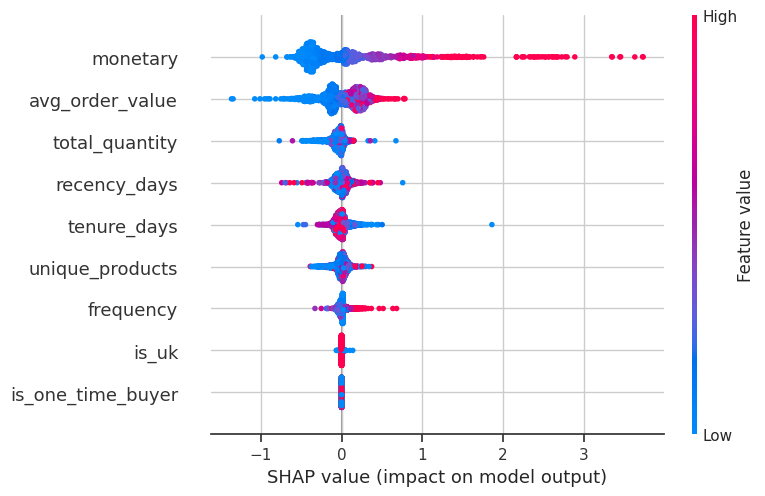

In [16]:
import shap
xgb_model = stage2_final.regressor_
explainer = shap.TreeExplainer(xgb_model)
X_returned = X.loc[y_binary == 1]
shap_values = explainer.shap_values(X_returned)

plt.figure()
shap.summary_plot(shap_values, X_returned, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/06_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


**Stage 1 (return probability):** `frequency` dominates by far — how *often* someone bought
matters more than recency or total spend for predicting return.

**Stage 2 (spend amount):** `monetary` and `avg_order_value` dominate — past spend patterns are
sticky among customers who do return.

## 8. Business Recommendations

1. **Segment customers into 4 tiers** (VIP / Upsell / Win-back / Low-priority) using predicted
   return probability x predicted spend, and tailor marketing spend accordingly.
2. **Prioritize frequency-building retention campaigns** (reorder reminders, subscription nudges)
   over one-off discount promotions.
3. **Reallocate marketing budget toward the top 20% of customers**, who generate ~75% of revenue.
4. **Treat the 43.9% non-return rate as an urgent, quantified churn metric.**
5. **Fix checkout-level customer ID tracking** to close the ~25% missing-CustomerID gap.

## 9. Future Improvements

- Acquire two full years of data for rolling-origin backtesting
- Add probabilistic CLV benchmarks (BG/NBD, Gamma-Gamma)
- Bayesian hyperparameter tuning (Optuna)
- Product-category-level features
- Deployment: FastAPI service, Streamlit dashboard, or Flask + CRM batch scoring
